In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/final_panel_data.csv')

Columns with missing values (8): ['brent_oil', 'inflation', 'fx_rate', 'ip', 'stock_index', 'terms_of_trade', 'reserves', 'debt']
Country coverage summary by sparse column:
                countries_with_any_missing  countries_with_complete_coverage
brent_oil                               39                                 2
terms_of_trade                          18                                23
debt                                     7                                34
ip                                       5                                36
stock_index                              3                                38
inflation                                3                                38
reserves                                 3                                38
fx_rate                                  1                                40
Country-column pairs with partial missingness (1%-99%):
isocode         column  percent_missing
    COL    stock_index        57.22222

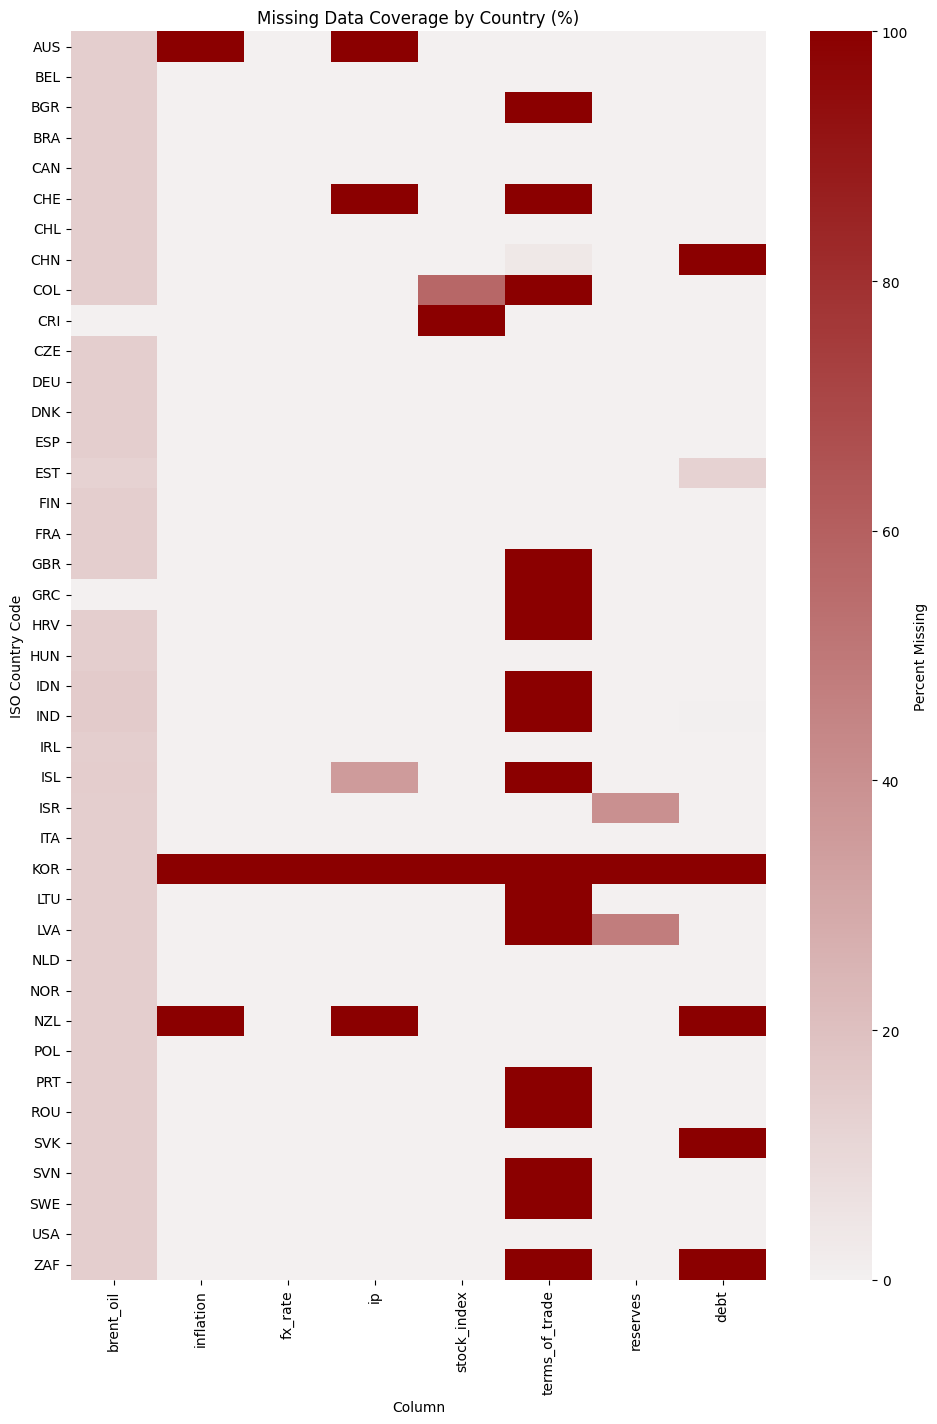

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sparse_cols = df.columns[df.isna().any()].tolist()
print(f"Columns with missing values ({len(sparse_cols)}): {sparse_cols}")

missing_pct_by_country = (
    df.groupby('isocode')[sparse_cols]
    .apply(lambda group: group.isna().mean() * 100)
    .sort_index()
)

country_missing_summary = pd.DataFrame({
    'countries_with_any_missing': (missing_pct_by_country.gt(0)).sum(),
    'countries_with_complete_coverage': (missing_pct_by_country.eq(0)).sum(),
}).sort_values('countries_with_any_missing', ascending=False)

print('Country coverage summary by sparse column:')
print(country_missing_summary)

partial_missingness = (
    missing_pct_by_country.stack()
    .rename('percent_missing')
    .reset_index()
    .query('0 < percent_missing < 100')
    .sort_values(['percent_missing', 'isocode', 'level_1'], ascending=[False, True, True])
    .rename(columns={'level_1': 'column'})
)

print('Country-column pairs with partial missingness (1%-99%):')
if partial_missingness.empty:
    print('None')
else:
    print(partial_missingness.to_string(index=False))

n_countries = len(missing_pct_by_country)
figsize = (max(len(sparse_cols) * 1.2, 6), max(n_countries * 0.35, 3))

plt.figure(figsize=figsize)
sns.heatmap(
    missing_pct_by_country,
    cmap=sns.light_palette('darkred', as_cmap=True),
    vmin=0,
    vmax=100,
    annot=n_countries < 20,
    fmt='.1f',
    cbar_kws={'label': 'Percent Missing'},
)
plt.title('Missing Data Coverage by Country (%)')
plt.xlabel('Column')
plt.ylabel('ISO Country Code')
plt.tight_layout()
plt.show()

In [4]:
df = df.loc[df["isocode"] != "KOR"].copy()

cols_to_drop = df.loc[:, "terms_of_trade":"date"].columns
df = df.drop(columns=cols_to_drop)

print(df.shape)
df.head()


(6933, 32)


,isocode,date,yield_10y,period,Competition and Sports,Health and Education,Military Conflict,Politics,Military Technology,National Development,...,vix,brent_oil,credit_spread,inflation,fx_rate,ip,stock_index,terms_of_trade,reserves,debt
0,AUS,1/1/2010,5.5575,201001,0.061398,0.073588,0.019415,0.019441,0.031388,0.067876,...,24.620001,71.459999,33.675831,NaN,1.096781,NaN,100.00000,1.000000,38864.08,19.242444
1,AUS,2/1/2010,5.4775,201002,0.062448,0.073145,0.020595,0.021634,0.036304,0.063547,...,19.500000,77.589996,34.042908,NaN,1.127445,NaN,92.23358,1.023580,36759.20,19.242444
2,AUS,3/1/2010,5.6200,201003,0.059424,0.075694,0.019563,0.022156,0.035235,0.072683,...,17.590000,82.699997,34.778976,NaN,1.095715,NaN,99.37471,1.059195,34988.19,19.242444
3,AUS,4/1/2010,5.7950,201004,0.055710,0.078934,0.019159,0.021588,0.041275,0.076524,...,22.049999,87.440002,35.447002,NaN,1.079094,NaN,103.29460,1.131496,38017.30,19.423733
4,AUS,5/1/2010,5.4800,201005,0.059780,0.075806,0.016951,0.023082,0.042158,0.076380,...,32.070000,74.019997,33.799465,NaN,1.152476,NaN,88.52134,1.173233,33339.69,19.423733


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional safety check: ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

THRESHOLDS = {
    "raw": 0.5,       # percentage-point change in yield
    "pct": 20.0,      # percent change
    "var_q": 0.90,    # quantile used to set spike_var threshold
    "dev_12m": 0.75,  # percentage points above trailing 12m mean
    "dev_6m": 0.75,   # percentage points above trailing 6m mean
    "dev_3m": 0.75,   # percentage points above trailing 3m mean
}


In [6]:
g = df.groupby("isocode", group_keys=False)

# 1. Month-over-month changes
df["delta_raw"] = g["yield_10y"].diff()
df["delta_pct"] = g["yield_10y"].pct_change() * 100

# 2. Trailing 12-month rolling variance of current yield
df["rolling_var_12"] = (
    g["yield_10y"]
    .transform(lambda s: s.rolling(window=12, min_periods=6).var())
)

# 3. Deviations from trailing means, excluding current month via shift(1)
rolling_mean_12 = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
rolling_mean_6 = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=6, min_periods=3).mean()
)
rolling_mean_3 = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=2).mean()
)

df["dev_from_mean_12m"] = df["yield_10y"] - rolling_mean_12
df["dev_from_mean_6m"] = df["yield_10y"] - rolling_mean_6
df["dev_from_mean_3m"] = df["yield_10y"] - rolling_mean_3

# Default variance threshold from observed distribution
threshold_var = df["rolling_var_12"].quantile(THRESHOLDS["var_q"])
print(f"Computed variance threshold (q={THRESHOLDS['var_q']:.2f}): {threshold_var:.4f}")


Computed variance threshold (q=0.90): 0.5643


In [7]:
# Spike flags
df["spike_raw"] = np.where(
    df["delta_raw"].notna(),
    df["delta_raw"] > THRESHOLDS["raw"],
    np.nan,
)

df["spike_pct"] = np.where(
    df["delta_pct"].notna(),
    df["delta_pct"] > THRESHOLDS["pct"],
    np.nan,
)

df["spike_var"] = np.where(
    df["rolling_var_12"].notna(),
    df["rolling_var_12"] > threshold_var,
    np.nan,
)

df["spike_dev_12m"] = np.where(
    df["dev_from_mean_12m"].notna(),
    df["dev_from_mean_12m"] > THRESHOLDS["dev_12m"],
    np.nan,
)

df["spike_dev_6m"] = np.where(
    df["dev_from_mean_6m"].notna(),
    df["dev_from_mean_6m"] > THRESHOLDS["dev_6m"],
    np.nan,
)

df["spike_dev_3m"] = np.where(
    df["dev_from_mean_3m"].notna(),
    df["dev_from_mean_3m"] > THRESHOLDS["dev_3m"],
    np.nan,
)


In [8]:
def make_onset(spike_series):
    prev_spike = spike_series.shift(1)
    onset = (spike_series == True) & (prev_spike.fillna(False) != True)
    onset = onset.astype("object")
    onset[spike_series.isna()] = np.nan
    return onset

df["onset_raw"] = g["spike_raw"].transform(make_onset)
df["onset_pct"] = g["spike_pct"].transform(make_onset)
df["onset_var"] = g["spike_var"].transform(make_onset)
df["onset_dev_12m"] = g["spike_dev_12m"].transform(make_onset)
df["onset_dev_6m"] = g["spike_dev_6m"].transform(make_onset)
df["onset_dev_3m"] = g["spike_dev_3m"].transform(make_onset)


       target  total_onset_events  onset_rate_pct  countries_with_at_least_one_onset  median_episodes_per_country
    onset_pct                 296        4.294212                                 35                          8.0
    onset_raw                 184        2.669375                                 37                          3.0
 onset_dev_6m                 136        1.996184                                 38                          2.5
 onset_dev_3m                 128        1.867795                                 35                          3.0
onset_dev_12m                 121        1.807859                                 39                          3.0
    onset_var                  74        1.099064                                 33                          2.0


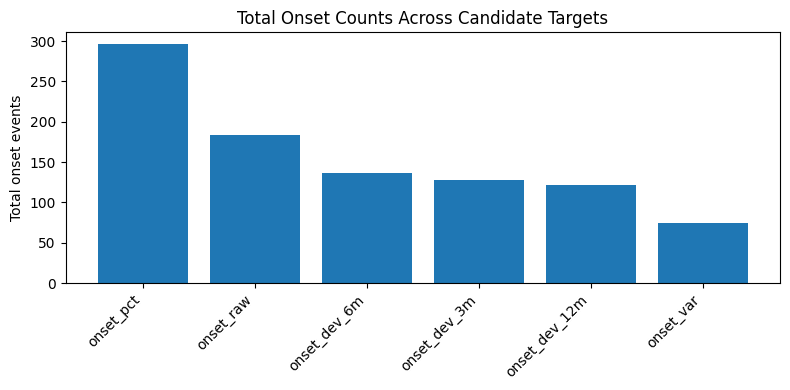

In [9]:
onset_cols = [
    "onset_raw",
    "onset_pct",
    "onset_var",
    "onset_dev_12m",
    "onset_dev_6m",
    "onset_dev_3m",
]

summary_rows = []

for col in onset_cols:
    valid = df[col].dropna()
    total_onsets = int(valid.sum()) if len(valid) else 0
    onset_rate = float(valid.mean() * 100) if len(valid) else np.nan

    by_country = (
        df.loc[df[col].notna()]
        .groupby("isocode")[col]
        .sum()
    )

    countries_with_onset = int((by_country > 0).sum()) if len(by_country) else 0
    median_episodes = (
        float(by_country[by_country > 0].median())
        if (by_country > 0).any()
        else np.nan
    )

    summary_rows.append({
        "target": col,
        "total_onset_events": total_onsets,
        "onset_rate_pct": onset_rate,
        "countries_with_at_least_one_onset": countries_with_onset,
        "median_episodes_per_country": median_episodes,
    })

summary = pd.DataFrame(summary_rows).sort_values("total_onset_events", ascending=False)

print(summary.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(summary["target"], summary["total_onset_events"])
plt.title("Total Onset Counts Across Candidate Targets")
plt.ylabel("Total onset events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


             rule  threshold  total_onsets  onset_rate_pct  countries_with_onset  median_episodes_per_country
dev_from_mean_12m       0.25           276        4.123711                    40                          7.0
dev_from_mean_12m       0.50           183        2.734200                    40                          4.0
dev_from_mean_12m       0.75           121        1.807859                    39                          3.0
dev_from_mean_12m       1.00           100        1.494098                    38                          2.0
dev_from_mean_12m       1.25            85        1.269984                    37                          2.0
dev_from_mean_12m       1.50            71        1.060810                    34                          2.0
        delta_raw       0.10          1004       14.565501                    40                         25.0
        delta_raw       0.25           505        7.326273                    40                         12.0
        de

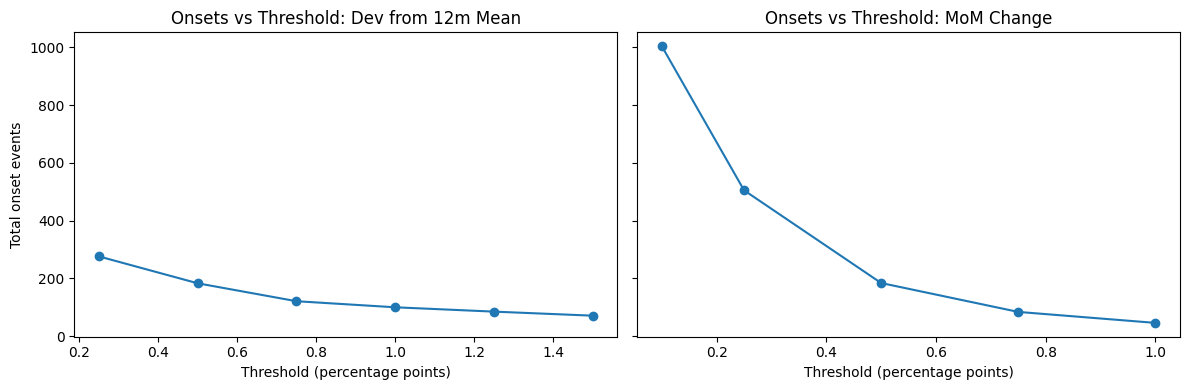

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = df.groupby("isocode", group_keys=False)

# Recompute the two underlying signals cleanly
df["delta_raw"] = g["yield_10y"].diff()

trailing_mean_12m = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

def make_onset_from_signal(signal, threshold):
    spike = pd.Series(np.where(signal.notna(), signal > threshold, np.nan), index=signal.index)
    
    def onset_with_nan(s):
        prev = s.shift(1)
        onset = (s == True) & (prev.fillna(False) != True)
        onset = onset.astype("object")
        onset[s.isna()] = np.nan
        return onset

    onset = spike.groupby(df["isocode"], group_keys=False).transform(onset_with_nan)
    return onset

# Threshold grids to tune
dev_thresholds = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50]   # percentage points above trailing mean
mom_thresholds = [0.10, 0.25, 0.50, 0.75, 1.00]         # percentage-point monthly increase

results = []

for th in dev_thresholds:
    onset = make_onset_from_signal(df["dev_from_mean_12m"], th)
    valid = onset.dropna()
    by_country = df.loc[onset.notna()].groupby("isocode")[onset.name if onset.name else "yield_10y"].size()
    
    country_events = onset.groupby(df["isocode"]).apply(lambda s: s.dropna().sum())
    countries_with_event = int((country_events > 0).sum())
    median_events = float(country_events[country_events > 0].median()) if (country_events > 0).any() else np.nan

    results.append({
        "rule": "dev_from_mean_12m",
        "threshold": th,
        "total_onsets": int(valid.sum()) if len(valid) else 0,
        "onset_rate_pct": float(valid.mean() * 100) if len(valid) else np.nan,
        "countries_with_onset": countries_with_event,
        "median_episodes_per_country": median_events,
    })

for th in mom_thresholds:
    onset = make_onset_from_signal(df["delta_raw"], th)
    valid = onset.dropna()

    country_events = onset.groupby(df["isocode"]).apply(lambda s: s.dropna().sum())
    countries_with_event = int((country_events > 0).sum())
    median_events = float(country_events[country_events > 0].median()) if (country_events > 0).any() else np.nan

    results.append({
        "rule": "delta_raw",
        "threshold": th,
        "total_onsets": int(valid.sum()) if len(valid) else 0,
        "onset_rate_pct": float(valid.mean() * 100) if len(valid) else np.nan,
        "countries_with_onset": countries_with_event,
        "median_episodes_per_country": median_events,
    })

tuning_summary = pd.DataFrame(results)
print(tuning_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

dev_plot = tuning_summary[tuning_summary["rule"] == "dev_from_mean_12m"]
mom_plot = tuning_summary[tuning_summary["rule"] == "delta_raw"]

axes[0].plot(dev_plot["threshold"], dev_plot["total_onsets"], marker="o")
axes[0].set_title("Onsets vs Threshold: Dev from 12m Mean")
axes[0].set_xlabel("Threshold (percentage points)")
axes[0].set_ylabel("Total onset events")

axes[1].plot(mom_plot["threshold"], mom_plot["total_onsets"], marker="o")
axes[1].set_title("Onsets vs Threshold: MoM Change")
axes[1].set_xlabel("Threshold (percentage points)")

plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd

# Adjustable threshold in percentage points
DEV_12M_THRESHOLD = 0.25

g = df.groupby("isocode", group_keys=False)

# Recompute trailing 12m mean excluding the current month
trailing_mean_12m = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)

df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

# Incidence: 1 whenever the country is above the threshold
df["incidence_dev_12m"] = np.where(
    df["dev_from_mean_12m"].notna(),
    df["dev_from_mean_12m"] > DEV_12M_THRESHOLD,
    np.nan,
)

# Onset: 1 only when it switches from not-spiking to spiking within country
def make_onset(spike_series):
    prev_spike = spike_series.shift(1)
    onset = (spike_series == True) & (prev_spike.fillna(False) != True)
    onset = onset.astype("object")
    onset[spike_series.isna()] = np.nan
    return onset

df["onset_dev_12m"] = g["incidence_dev_12m"].transform(make_onset)

print(f"Using DEV_12M_THRESHOLD = {DEV_12M_THRESHOLD:.2f} percentage points")


Using DEV_12M_THRESHOLD = 0.25 percentage points


In [12]:
# Change this list to whatever countries you want to inspect
sample_countries = df["isocode"].dropna().unique()[:3].tolist()

cols_to_show = [
    "isocode",
    "date",
    "yield_10y",
    "dev_from_mean_12m",
    "incidence_dev_12m",
    "onset_dev_12m",
]

for country in sample_countries:
    print(f"\n===== {country} =====")
    display(
        df.loc[df["isocode"] == country, cols_to_show]
        .sort_values("date")
        .reset_index(drop=True)
        .tail(24)
    )



===== AUS =====


,isocode,date,yield_10y,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m
156,AUS,2023-01-01,3.604,0.407500,1.0,False
157,AUS,2023-02-01,3.702,0.362500,1.0,False
158,AUS,2023-03-01,3.468,-0.004083,0.0,False
159,AUS,2023-04-01,3.343,-0.209750,0.0,False
160,AUS,2023-05-01,3.500,-0.080667,0.0,False
161,AUS,2023-06-01,3.916,0.325417,1.0,True
162,AUS,2023-07-01,4.036,0.433000,1.0,False
163,AUS,2023-08-01,4.128,0.474417,1.0,False
164,AUS,2023-09-01,4.211,0.493500,1.0,False
165,AUS,2023-10-01,4.633,0.876833,1.0,False



===== BEL =====


,isocode,date,yield_10y,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m
156,BEL,2023-01-01,2.79,1.056667,1.0,False
157,BEL,2023-02-01,2.96,1.015833,1.0,False
158,BEL,2023-03-01,3.04,0.898333,1.0,False
159,BEL,2023-04-01,3.05,0.720833,1.0,False
160,BEL,2023-05-01,3.04,0.565000,1.0,False
161,BEL,2023-06-01,3.05,0.453333,1.0,False
162,BEL,2023-07-01,3.14,0.466667,1.0,False
163,BEL,2023-08-01,3.22,0.435000,1.0,False
164,BEL,2023-09-01,3.32,0.409167,1.0,False
165,BEL,2023-10-01,3.52,0.536667,1.0,False



===== BGR =====


,isocode,date,yield_10y,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m
156,BGR,2023-01-01,1.85,0.318333,1.0,False
157,BGR,2023-02-01,2.73,1.091667,1.0,False
158,BGR,2023-03-01,4.21,2.395000,1.0,False
159,BGR,2023-04-01,4.03,1.955000,1.0,False
160,BGR,2023-05-01,4.03,1.754167,1.0,False
161,BGR,2023-06-01,4.03,1.553333,1.0,False
162,BGR,2023-07-01,4.03,1.365000,1.0,False
163,BGR,2023-08-01,4.03,1.183333,1.0,False
164,BGR,2023-09-01,4.03,1.001667,1.0,False
165,BGR,2023-10-01,4.03,0.820000,1.0,False


Threshold-level summary:


,threshold,incidence_total_months,incidence_rate_pct,onset_total_events,onset_rate_pct,countries_with_incidence,countries_with_onset,country_incidence_balance_mean_pct,country_incidence_balance_min_pct,country_incidence_balance_max_pct,country_incidence_balance_var,country_onset_balance_mean_pct,country_onset_balance_min_pct,country_onset_balance_max_pct,country_onset_balance_var
0,0.2,1875,28.014343,313,4.676528,40,40,28.269303,7.471264,42.857143,0.004602,4.612572,1.149425,7.333333,0.000265
1,0.3,1552,23.188406,254,3.795010,40,40,23.497471,6.896552,40.816327,0.004573,3.768156,1.149425,7.333333,0.000214
2,0.4,1298,19.393396,219,3.272075,40,40,19.753379,6.349206,40.816327,0.004841,3.262903,1.149425,7.471264,0.000195
3,0.5,1033,15.434036,183,2.734200,40,40,15.814906,3.968254,36.734694,0.004932,2.735451,1.149425,7.471264,0.000178
4,0.6,863,12.894068,158,2.360675,39,39,13.220209,0.000000,32.653061,0.004581,2.373228,0.000000,6.164384,0.000209
5,0.7,746,11.145973,129,1.927387,39,39,11.411537,0.000000,28.571429,0.004153,1.939777,0.000000,5.172414,0.000159
6,0.8,633,9.457642,113,1.688331,39,39,9.755480,0.000000,28.571429,0.003903,1.694840,0.000000,5.172414,0.000168



Country-threshold balance summary (first 20 rows):


,isocode,threshold,incidence_balance_pct,onset_balance_pct
0,AUS,0.2,28.160920,6.896552
1,BEL,0.2,26.436782,5.172414
2,BGR,0.2,18.390805,2.873563
3,BRA,0.2,31.034483,2.298851
4,CAN,0.2,29.310345,6.896552
5,CHE,0.2,20.689655,6.321839
6,CHL,0.2,20.114943,2.873563
7,CHN,0.2,15.873016,1.587302
8,COL,0.2,35.632184,6.321839
9,CRI,0.2,40.000000,4.516129


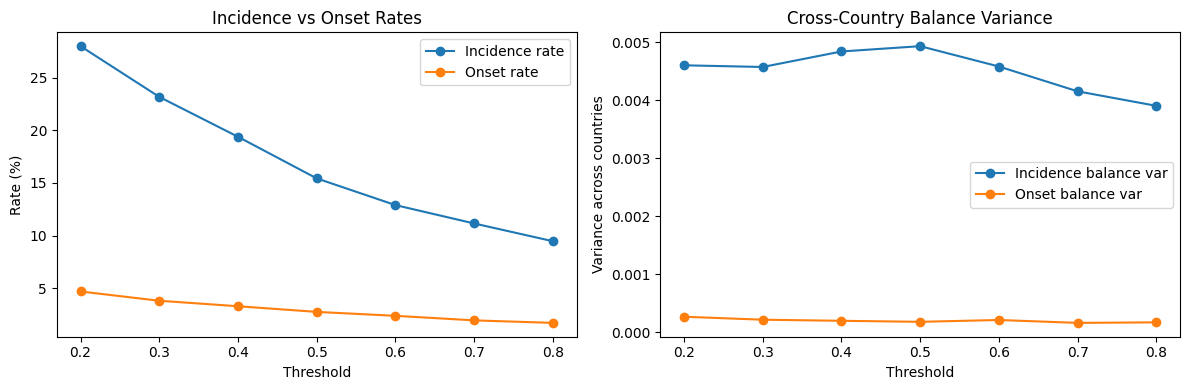

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Threshold grid to search
threshold_grid = np.round(np.arange(0.2, 0.81, 0.1), 2)

g = df.groupby("isocode", group_keys=False)

# Recompute dev_from_mean_12m cleanly
trailing_mean_12m = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

summary_rows = []
country_balance_rows = []

for th in threshold_grid:
    incidence = pd.Series(
        np.where(
            df["dev_from_mean_12m"].notna(),
            df["dev_from_mean_12m"] > th,
            np.nan,
        ),
        index=df.index,
        name=f"incidence_dev_12m_{th:.2f}",
    )

    def make_onset(spike_series):
        prev_spike = spike_series.shift(1)
        onset = (spike_series == True) & (prev_spike.fillna(False) != True)
        onset = onset.astype("object")
        onset[spike_series.isna()] = np.nan
        return onset

    onset = incidence.groupby(df["isocode"], group_keys=False).transform(make_onset)
    onset.name = f"onset_dev_12m_{th:.2f}"

    incidence_valid = incidence.dropna()
    onset_valid = onset.dropna()

    incidence_by_country = (
        pd.DataFrame({"isocode": df["isocode"], "incidence": incidence})
        .dropna(subset=["incidence"])
        .groupby("isocode")["incidence"]
        .mean()
    )

    onset_by_country = (
        pd.DataFrame({"isocode": df["isocode"], "onset": onset})
        .dropna(subset=["onset"])
        .groupby("isocode")["onset"]
        .mean()
    )

    summary_rows.append({
        "threshold": th,
        "incidence_total_months": int(incidence_valid.sum()) if len(incidence_valid) else 0,
        "incidence_rate_pct": float(incidence_valid.mean() * 100) if len(incidence_valid) else np.nan,
        "onset_total_events": int(onset_valid.sum()) if len(onset_valid) else 0,
        "onset_rate_pct": float(onset_valid.mean() * 100) if len(onset_valid) else np.nan,
        "countries_with_incidence": int((incidence_by_country > 0).sum()) if len(incidence_by_country) else 0,
        "countries_with_onset": int((onset_by_country > 0).sum()) if len(onset_by_country) else 0,
        "country_incidence_balance_mean_pct": float(incidence_by_country.mean() * 100) if len(incidence_by_country) else np.nan,
        "country_incidence_balance_min_pct": float(incidence_by_country.min() * 100) if len(incidence_by_country) else np.nan,
        "country_incidence_balance_max_pct": float(incidence_by_country.max() * 100) if len(incidence_by_country) else np.nan,
        "country_incidence_balance_var": float(incidence_by_country.var()) if len(incidence_by_country) else np.nan,
        "country_onset_balance_mean_pct": float(onset_by_country.mean() * 100) if len(onset_by_country) else np.nan,
        "country_onset_balance_min_pct": float(onset_by_country.min() * 100) if len(onset_by_country) else np.nan,
        "country_onset_balance_max_pct": float(onset_by_country.max() * 100) if len(onset_by_country) else np.nan,
        "country_onset_balance_var": float(onset_by_country.var()) if len(onset_by_country) else np.nan,
    })

    tmp_country = pd.DataFrame({
        "isocode": incidence_by_country.index,
        "threshold": th,
        "incidence_balance_pct": incidence_by_country.values * 100,
        "onset_balance_pct": onset_by_country.reindex(incidence_by_country.index).values * 100,
    })
    country_balance_rows.append(tmp_country)

threshold_summary = pd.DataFrame(summary_rows).sort_values("threshold")
country_balance_summary = pd.concat(country_balance_rows, ignore_index=True)

print("Threshold-level summary:")
display(threshold_summary)

print("\nCountry-threshold balance summary (first 20 rows):")
display(country_balance_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(threshold_summary["threshold"], threshold_summary["incidence_rate_pct"], marker="o", label="Incidence rate")
axes[0].plot(threshold_summary["threshold"], threshold_summary["onset_rate_pct"], marker="o", label="Onset rate")
axes[0].set_title("Incidence vs Onset Rates")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Rate (%)")
axes[0].legend()

axes[1].plot(threshold_summary["threshold"], threshold_summary["country_incidence_balance_var"], marker="o", label="Incidence balance var")
axes[1].plot(threshold_summary["threshold"], threshold_summary["country_onset_balance_var"], marker="o", label="Onset balance var")
axes[1].set_title("Cross-Country Balance Variance")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Variance across countries")
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import numpy as np
from panelsplit.cross_validation import PanelSplit
from panelsplit.application import cross_val_fit_predict
from typing import Union
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
df = pd.read_csv("../data/final_panel_data.csv")
df = df.sort_values(["isocode", "period"]).reset_index(drop=True)
df = df.set_index(["isocode", "period"]).sort_index()

df.head()


date  yield_10y  Competition and Sports  \
isocode period                                                
AUS     201001  1/1/2010     5.5575                0.061398   
        201002  2/1/2010     5.4775                0.062448   
        201003  3/1/2010     5.6200                0.059424   
        201004  4/1/2010     5.7950                0.055710   
        201005  5/1/2010     5.4800                0.059780   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
AUS     201001              0.073588           0.019415  0.019441   
        201002              0.073145           0.020595  0.021634   
        201003              0.075694           0.019563  0.022156   
        201004              0.078934           0.019159  0.021588   
        201005              0.075806           0.016951  0.023082   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
AUS     201001             0.031388              0.067876            0.110389   
        201002             0.036304              0.063547            0.114383   
        201003             0.035235              0.072683            0.113926   
        201004             0.041275              0.076524            0.116547   
        201005             0.042158              0.076380            0.120453   

                Judiciary and Abuses  ...        vix  brent_oil  \
isocode period                        ...                         
AUS     201001              0.090134  ...  24.620001  71.459999   
        201002              0.095505  ...  19.500000  77.589996   
        201003              0.100099  ...  17.590000  82.699997   
        201004              0.099836  ...  22.049999  87.440002   
        201005              0.099477  ...  32.070000  74.019997   

                credit_spread  inflation   fx_rate  ip  stock_index  \
isocode period                                                        
AUS     201001      33.675831        NaN  1.096781 NaN    100.00000   
        201002      34.042908        NaN  1.127445 NaN     92.23358   
        201003      34.778976        NaN  1.095715 NaN     99.37471   
        201004      35.447002        NaN  1.079094 NaN    103.29460   
        201005      33.799465        NaN  1.152476 NaN     88.52134   

                terms_of_trade  reserves       debt  
isocode period                                       
AUS     201001        1.000000  38864.08  19.242444  
        201002        1.023580  36759.20  19.242444  
        201003        1.059195  34988.19  19.242444  
        201004        1.131496  38017.30  19.423733  
        201005        1.173233  33339.69  19.423733  

[5 rows x 30 columns]

In [16]:
class FeatureEngineer:

    """
    This is a class that contains general methods that can be applied to a DataFrame to create new features. Examples of such methods include creating lagged variables, rolling min/mean/max/sum and weighted rolling mean/sum.
    The methods in this class are designed to be used in a pipeline to create new features for a given DataFrame.

    Attributes:
    -----------
    groupby_cols : Union[str, list]
        A str or list of columns to group by

    Methods:
    --------

    lag(input_df:pd.DataFrame, y_col:str, lags:list):
        This is a method that creates lagged variables for a given column in a DataFrame.

    rolling_sum(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):
        This is a method that creates the rolling sum of specified windows for a given column in a DataFrame.

    rolling_mean(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):
        This is a method that creates the rolling mean of specified windows for a given column in a DataFrame.

    rolling_min(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):
        This is a method that creates the rolling min of specified windows for a given column in a DataFrame.

    rolling_max(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):
        This is a method that creates the rolling max of specified windows for a given column in a DataFrame.

    rolling_std(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):
        This is a method that creates the rolling standard deviation of specified windows for a given column in a DataFrame.

    create_exponential_weights(window_size, alpha=0.8):
        This is a method that enables generating "rolling" exponential weights for a given window size.

    weighted_rolling_sum(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):
        This is a method that creates the weighted rolling sum of specified windows for a given column in a DataFrame.

    weighted_rolling_mean(input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):
        This is a method that creates the weighted rolling mean of specified windows for a given column in a DataFrame.

    count_since(input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):
        This is a method that counts the number of periods since a variable has been above a given threshold.

    ongoing(input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):
        This is a method that represents a sequential count of the number of periods for which a variable has been above a given threshold.

    Notes:
    -------
    Be very careful with NAs when using the count_since_thresh and ongoing_episode methods.
    The way we are computing things here (i.e. using a > th condition) means they are treated as a 0/False.
    """

    def __init__(self, groupby_cols: Union[str, list]):

        self.groupby_cols = groupby_cols

    def _index_check(self, df:pd.DataFrame):

        """
        This is a method that checks if the index of a DataFrame is sorted correctly.

        Args:
        -----
        :param df: The DataFrame to check.

        Returns:
        --------
        :return: The DataFrame with a sorted index.
        """

        assert df.index.is_monotonic_increasing, "The index of the DataFrame should be monotonically increasing."

    def lag(self, input_df:pd.DataFrame, y_col:str, lags:list):

        """
        This is a method that creates lagged variables for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create lagged variables.
        :param lags: A list of lag values to create.

        Returns:
        --------
        :return: The original DataFrame with the lagged variables appended.
        """
        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_basic_lag' + str(lag) for lag in lags]
        for idx, lag in enumerate(lags):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].shift(lag)
        return df

    def rolling_sum(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        """
        This is a method that creates the rolling sum of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create lagged variables.
        :param groupby_cols: A list of columns to group by.
        :param windows: A list of windows to generate a rolling sum for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs: A boolean indicating whether to return the log of the rolling sum.

        Returns:
        --------
        :return: The original DataFrame with the rolling sum variables appended.

        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_sum' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).sum().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_mean(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        """
        This is a method that creates the rolling mean of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create rolling variables.
        :param windows: A list of windows to generate a rolling mean for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs: A boolean indicating whether to return the log of the rolling mean.

        Returns:
        --------
        :return: The original DataFrame with the rolling mean variables appended.

        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_mean' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).mean().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_min(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        """
        This is a method that creates the rolling min of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create rolling variables.
        :param windows: A list of windows to generate a rolling min for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs: A boolean indicating whether to return the log of the rolling min.

        Returns:
        --------
        :return: The original DataFrame with the rolling min variables appended.

        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_min' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).min().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_max(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        """
        This is a method that creates the rolling max of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create rolling variables.
        :param windows: A list of windows to generate a rolling max for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs: A boolean indicating whether to return the log of the rolling max.

        Returns:
        --------
        :return: The original DataFrame with the rolling max variables appended.

        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_max' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).max().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_std(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        """
        This is a method that creates the rolling standard deviation of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create rolling variables.
        :param windows: A list of windows to generate a rolling standard deviation for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs: A boolean indicating whether to return the log of the rolling standard deviation.

        Returns:
        --------
        :return: The original DataFrame with the rolling standard deviation variables appended.

        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_std' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).std().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def _create_exponential_weights(self, window_size, alpha=0.8):

        """
        This is a method that enables generating "rolling" exponential weights for a given window size.

        Args:
        -----
        :param window_size: The size of the window for which weights are calculated.
        :param alpha: The decay factor for weights, defaults to 0.5.
                    A higher alpha discounts older observations faster.

        Returns:
        -----
        :return: A numpy array of weights.
        """

        weights = alpha ** np.arange(window_size)
        normalized_weights = weights / weights.sum()
        return normalized_weights[::-1]

    def weighted_rolling_sum(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):

        """
        This is a method that creates the weighted rolling sum of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create weighted rolling variables.
        :param groupby_cols: A list of columns to group by.
        :param windows: A list of windows to generate a weighted rolling sum for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs:  A boolean indicating whether to return the log of the weighted rolling sum.
        :param alpha: The decay factor for weights, defaults to 0.8. A higher alpha discounts older observations faster.

        Returns:
        -----
        :return: The original DataFrame with the weighted rolling sum variables appended.
        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_weighted_rolling_sum' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).apply(lambda x: np.sum(self._create_exponential_weights(len(x), alpha) * x), raw = True).values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def weighted_rolling_mean(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):
        """
        This is a method that creates the weighted rolling mean of specified windows for a given column in a DataFrame.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create weighted rolling variables.
        :param windows: A list of windows to generate a weighted rolling mean for.
        :param closed: A string indicating the side of the window interval to close on. Closed = 'left' omits the current observation.
        :param return_logs:  A boolean indicating whether to return the log of the weighted rolling mean.
        :param alpha: The decay factor for weights, defaults to 0.8. A higher alpha discounts older observations faster.

        Returns:
        --------
        :return: The original DataFrame with the weighted rolling mean variables appended.
        """

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_weighted_rolling_mean' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).apply(lambda x: np.sum(self._create_exponential_weights(len(x), alpha) * x) / len(x), raw = True).values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def _count_since(self, x: pd.Series):
        """
        This is a method that counts the number of periods since a variable has been 1.

        :param x: A pandas Series containing the target variable.

        Returns:
        - y (list): A list containing the number of periods since the target variable has been 1.
        """

        x = list(x)
        y = []
        for n in range(0, len(x)):
            if (x[n] == 0) & (n == 0):
                y.append(1) # if it starts with no flows
            elif x[n] == 1:
                y.append(0) # reset to 0 if flows
            else:
                y.append(y[n-1]+1) # add 1 if no flows
        return y

    def since(self, input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):

        """
        This is a method that counts the number of periods since a variable has been above a given threshold.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create the count since variable.
        :param thresholds: A list of thresholds to count since.
        :param shift_knowledge: An integer defining by how many periods to shift the count since variable.

        Returns:
        --------
        :return: The original DataFrame with the count since variables appended.
        """

        df = input_df.copy()

        self._index_check(df)


        binary_col_names = [y_col + '_above' + str(th) for th in thresholds]
        col_names = [y_col + '_since_' + str(th) for th in thresholds]

        for idx, th in enumerate(thresholds):
            df[binary_col_names[idx]] = (df[y_col] > th).astype(int)
            df[col_names[idx]] = df.groupby(self.groupby_cols)[binary_col_names[idx]].transform(self._count_since)

            if shift_knowledge is None:
                pass
            else:
                #in case we need to shift by one since we don't know the y_col in current period
                df[binary_col_names[idx]] = df.groupby(self.groupby_cols)[[binary_col_names[idx]]].shift(shift_knowledge)
                df[col_names[idx]] = df.groupby(self.groupby_cols)[col_names[idx]].shift(shift_knowledge)
        return df[[y_col, *[x for x in df.columns if 'since' in x]]]

    def _count_ongoing(self, x: pd.Series):
        """
        This is a method that generates a sequential count of the periods for which a variable has been 1.

        :param x: A pandas Series containing the target variable.

        Returns:
        - y (list): A list containing the sequential count of the periods for which the target variable has been 1.
        """

        x = list(x)
        y = []
        episode_counter = 0
        for n in range(0, len(x)):
            if (x[n] == 0) & (n == 0):
                y.append(episode_counter) # if it starts with no flows
            elif x[n] == 1:
                episode_counter += 1
                y.append(episode_counter) # if there are flows
            else:
                y.append(0) # reset to 0 if no flows
                episode_counter = 0
        return y

    def ongoing(self, input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):

        """
        This is a method that represents a sequential count of the number of periods for which a variable has been above a given threshold.

        Args:
        -----
        :param input_df: The DataFrame containing the data.
        :param y_col: The name of the column for which to create the count since variable.
        :param thresholds: A list of thresholds to count since.
        :param shift_knowledge: An integer defining by how many periods to shift the count since variable.

        Returns:
        --------
        :return: The original DataFrame with the count since variables appended.
        """

        df = input_df.copy()

        self._index_check(df)

        binary_col_names = [y_col + '_above' + str(th) for th in thresholds]
        col_names = [y_col + '_ongoing_' + str(th) for th in thresholds]

        for idx, th in enumerate(thresholds):
            df[binary_col_names[idx]] = (df[y_col] > th).astype(int)
            df[col_names[idx]] = df.groupby(self.groupby_cols)[binary_col_names[idx]].transform(self._count_ongoing)

            if shift_knowledge is None:
                pass
            else:
                #in case we need to shift by one since we don't know the y_col in current period
                df[binary_col_names[idx]] = df.groupby(self.groupby_cols)[[binary_col_names[idx]]].shift(shift_knowledge)
                df[col_names[idx]] = df.groupby(self.groupby_cols)[col_names[idx]].shift(shift_knowledge)
        return df[[y_col, *[x for x in df.columns if 'ongoing' in x]]]


In [17]:
fe = FeatureEngineer(groupby_cols="isocode")


In [18]:
DEV_12M_THRESHOLD = 0.25

trailing_mean_12m = df.groupby("isocode")["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

df["incidence_dev_12m"] = np.where(
    df["dev_from_mean_12m"].notna(),
    (df["dev_from_mean_12m"] > DEV_12M_THRESHOLD).astype(float),
    np.nan,
)

def make_onset(s):
    prev = s.shift(1)
    onset = (s == 1.0) & (prev.fillna(0.0) != 1.0)
    onset = onset.astype("object")
    onset[s.isna()] = np.nan
    return onset

df["onset_dev_12m"] = df.groupby("isocode")["incidence_dev_12m"].transform(make_onset)

print(df[["yield_10y", "dev_from_mean_12m", "incidence_dev_12m", "onset_dev_12m"]].head(100))


                yield_10y  dev_from_mean_12m  incidence_dev_12m onset_dev_12m
isocode period                                                               
AUS     201001     5.5575                NaN                NaN           NaN
        201002     5.4775                NaN                NaN           NaN
        201003     5.6200                NaN                NaN           NaN
        201004     5.7950                NaN                NaN           NaN
        201005     5.4800                NaN                NaN           NaN
...                   ...                ...                ...           ...
        201712     2.5830          -0.076250                0.0         False
        201801     2.7470           0.105750                0.0         False
        201802     2.8450           0.200750                0.0         False
        201803     2.7130           0.059833                0.0         False
        201804     2.7340           0.088417                0.0 

In [19]:
y_col = "yield_10y"

example_iso = "USA"
example_cond = df.index.get_level_values("isocode") == example_iso

df[example_cond].tail(12)


date  yield_10y  Competition and Sports  \
isocode period                                                 
USA     202401   1/1/2024       4.06                0.111846   
        202402   2/1/2024       4.21                0.110218   
        202403   3/1/2024       4.21                0.112104   
        202404   4/1/2024       4.54                0.105775   
        202405   5/1/2024       4.48                0.098763   
        202406   6/1/2024       4.31                0.101889   
        202407   7/1/2024       4.25                0.113341   
        202408   8/1/2024       3.87                0.130912   
        202409   9/1/2024       3.72                0.128588   
        202410  10/1/2024       4.10                0.122318   
        202411  11/1/2024       4.36                0.128106   
        202412  12/1/2024       4.39                0.123621   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
USA     202401              0.033146           0.057230  0.024251   
        202402              0.031107           0.056956  0.024301   
        202403              0.030645           0.055786  0.025585   
        202404              0.029397           0.054652  0.025377   
        202405              0.028509           0.054545  0.026415   
        202406              0.029766           0.052489  0.027262   
        202407              0.029500           0.048666  0.029211   
        202408              0.028237           0.047201  0.030374   
        202409              0.028595           0.048355  0.030693   
        202410              0.028599           0.050753  0.031762   
        202411              0.029394           0.049652  0.034394   
        202412              0.028348           0.049594  0.033145   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
USA     202401             0.087744              0.039211            0.241998   
        202402             0.086201              0.038995            0.251261   
        202403             0.082416              0.038446            0.250317   
        202404             0.088569              0.038877            0.255575   
        202405             0.090702              0.038485            0.255529   
        202406             0.089997              0.038692            0.248188   
        202407             0.086071              0.037955            0.243823   
        202408             0.080955              0.036877            0.236221   
        202409             0.079291              0.038244            0.236278   
        202410             0.083257              0.037359            0.239102   
        202411             0.081826              0.036516            0.243260   
        202412             0.079181              0.040105            0.243607   

                Judiciary and Abuses  ...  inflation  fx_rate            ip  \
isocode period                        ...                                     
USA     202401              0.081520  ...   3.088343      1.0  2.690000e+11   
        202402              0.079122  ...   3.157074      1.0  2.720000e+11   
        202403              0.080752  ...   3.486835      1.0  2.720000e+11   
        202404              0.078246  ...   3.360795      1.0  2.720000e+11   
        202405              0.080466  ...   3.244279      1.0  2.730000e+11   
        202406              0.083029  ...   2.970258      1.0  2.730000e+11   
        202407              0.081106  ...   2.941476      1.0  2.710000e+11   
        202408              0.083770  ...   2.607144      1.0  2.720000e+11   
        202409              0.084621  ...   2.426483      1.0  2.710000e+11   
        202410              0.084714  ...   2.578844      1.0  2.700000e+11   
        202411              0.083874  ...   2.719472      1.0  2.690000e+1

In [20]:
windows = [1, 3, 6, 12, 36, 60]

naive_features_df = fe.rolling_mean(df, y_col, windows, closed="left")

naive_features_df[example_cond].tail(12)


date  yield_10y  Competition and Sports  \
isocode period                                                 
USA     202401   1/1/2024       4.06                0.111846   
        202402   2/1/2024       4.21                0.110218   
        202403   3/1/2024       4.21                0.112104   
        202404   4/1/2024       4.54                0.105775   
        202405   5/1/2024       4.48                0.098763   
        202406   6/1/2024       4.31                0.101889   
        202407   7/1/2024       4.25                0.113341   
        202408   8/1/2024       3.87                0.130912   
        202409   9/1/2024       3.72                0.128588   
        202410  10/1/2024       4.10                0.122318   
        202411  11/1/2024       4.36                0.128106   
        202412  12/1/2024       4.39                0.123621   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
USA     202401              0.033146           0.057230  0.024251   
        202402              0.031107           0.056956  0.024301   
        202403              0.030645           0.055786  0.025585   
        202404              0.029397           0.054652  0.025377   
        202405              0.028509           0.054545  0.026415   
        202406              0.029766           0.052489  0.027262   
        202407              0.029500           0.048666  0.029211   
        202408              0.028237           0.047201  0.030374   
        202409              0.028595           0.048355  0.030693   
        202410              0.028599           0.050753  0.031762   
        202411              0.029394           0.049652  0.034394   
        202412              0.028348           0.049594  0.033145   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
USA     202401             0.087744              0.039211            0.241998   
        202402             0.086201              0.038995            0.251261   
        202403             0.082416              0.038446            0.250317   
        202404             0.088569              0.038877            0.255575   
        202405             0.090702              0.038485            0.255529   
        202406             0.089997              0.038692            0.248188   
        202407             0.086071              0.037955            0.243823   
        202408             0.080955              0.036877            0.236221   
        202409             0.079291              0.038244            0.236278   
        202410             0.083257              0.037359            0.239102   
        202411             0.081826              0.036516            0.243260   
        202412             0.079181              0.040105            0.243607   

                Judiciary and Abuses  ...        debt  dev_from_mean_12m  \
isocode period                        ...                                  
USA     202401              0.081520  ...  118.354556           0.102500   
        202402              0.079122  ...  118.354556           0.208333   
        202403              0.080752  ...  118.354556           0.170000   
        202404              0.078246  ...  120.163573           0.454167   
        202405              0.080466  ...  120.163573           0.304167   
        202406              0.083029  ...  120.163573           0.058333   
        202407              0.081106  ...  121.665865          -0.048333   
        202408              0.083770  ...  121.665865          -0.457500   
        202409              0.084621  ...  121.665865          -0.582500   
        202410              0.084714  ...  122.958726          -0.147500   
        202411              0.083874  ...  122.958726           0.170833   
        202412              0.0839

In [21]:
example_cond = naive_features_df.index.get_level_values("isocode") == example_iso

print(naive_features_df.shape)
naive_features_df[example_cond].tail(12)


(7113, 39)


date  yield_10y  Competition and Sports  \
isocode period                                                 
USA     202401   1/1/2024       4.06                0.111846   
        202402   2/1/2024       4.21                0.110218   
        202403   3/1/2024       4.21                0.112104   
        202404   4/1/2024       4.54                0.105775   
        202405   5/1/2024       4.48                0.098763   
        202406   6/1/2024       4.31                0.101889   
        202407   7/1/2024       4.25                0.113341   
        202408   8/1/2024       3.87                0.130912   
        202409   9/1/2024       3.72                0.128588   
        202410  10/1/2024       4.10                0.122318   
        202411  11/1/2024       4.36                0.128106   
        202412  12/1/2024       4.39                0.123621   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
USA     202401              0.033146           0.057230  0.024251   
        202402              0.031107           0.056956  0.024301   
        202403              0.030645           0.055786  0.025585   
        202404              0.029397           0.054652  0.025377   
        202405              0.028509           0.054545  0.026415   
        202406              0.029766           0.052489  0.027262   
        202407              0.029500           0.048666  0.029211   
        202408              0.028237           0.047201  0.030374   
        202409              0.028595           0.048355  0.030693   
        202410              0.028599           0.050753  0.031762   
        202411              0.029394           0.049652  0.034394   
        202412              0.028348           0.049594  0.033145   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
USA     202401             0.087744              0.039211            0.241998   
        202402             0.086201              0.038995            0.251261   
        202403             0.082416              0.038446            0.250317   
        202404             0.088569              0.038877            0.255575   
        202405             0.090702              0.038485            0.255529   
        202406             0.089997              0.038692            0.248188   
        202407             0.086071              0.037955            0.243823   
        202408             0.080955              0.036877            0.236221   
        202409             0.079291              0.038244            0.236278   
        202410             0.083257              0.037359            0.239102   
        202411             0.081826              0.036516            0.243260   
        202412             0.079181              0.040105            0.243607   

                Judiciary and Abuses  ...        debt  dev_from_mean_12m  \
isocode period                        ...                                  
USA     202401              0.081520  ...  118.354556           0.102500   
        202402              0.079122  ...  118.354556           0.208333   
        202403              0.080752  ...  118.354556           0.170000   
        202404              0.078246  ...  120.163573           0.454167   
        202405              0.080466  ...  120.163573           0.304167   
        202406              0.083029  ...  120.163573           0.058333   
        202407              0.081106  ...  121.665865          -0.048333   
        202408              0.083770  ...  121.665865          -0.457500   
        202409              0.084621  ...  121.665865          -0.582500   
        202410              0.084714  ...  122.958726          -0.147500   
        202411              0.083874  ...  122.958726           0.170833   
        202412              0.0839

In [22]:
df = df.reset_index()
naive_features_df = naive_features_df.reset_index()
example_cond = naive_features_df["isocode"] == example_iso

print(df.shape)
print(naive_features_df.shape)
naive_features_df[example_cond].tail(12)


(7113, 35)
(7113, 41)


,isocode,period,date,yield_10y,Competition and Sports,Health and Education,Military Conflict,Politics,Military Technology,National Development,...,debt,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m,yield_10y_rolling_mean1,yield_10y_rolling_mean3,yield_10y_rolling_mean6,yield_10y_rolling_mean12,yield_10y_rolling_mean36,yield_10y_rolling_mean60
6921,USA,202401,1/1/2024,4.06,0.111846,0.033146,0.057230,0.024251,0.087744,0.039211,...,118.354556,0.102500,0.0,False,4.02,4.440000,4.295000,3.957500,2.783889,2.278000
6922,USA,202402,2/1/2024,4.21,0.110218,0.031107,0.056956,0.024301,0.086201,0.038995,...,118.354556,0.208333,0.0,False,4.06,4.193333,4.321667,4.001667,2.866667,2.300500
6923,USA,202403,3/1/2024,4.21,0.112104,0.030645,0.055786,0.025585,0.082416,0.038446,...,118.354556,0.170000,0.0,False,4.21,4.096667,4.328333,4.040000,2.948611,2.326000
6924,USA,202404,4/1/2024,4.54,0.105775,0.029397,0.054652,0.025377,0.088569,0.038877,...,120.163573,0.454167,1.0,True,4.21,4.160000,4.300000,4.085833,3.020833,2.353333
6925,USA,202405,5/1/2024,4.48,0.098763,0.028509,0.054545,0.026415,0.090702,0.038485,...,120.163573,0.304167,1.0,False,4.54,4.320000,4.256667,4.175833,3.101389,2.386833
6926,USA,202406,6/1/2024,4.31,0.101889,0.029766,0.052489,0.027262,0.089997,0.038692,...,120.163573,0.058333,0.0,False,4.48,4.410000,4.253333,4.251667,3.180833,2.421500
6927,USA,202407,7/1/2024,4.25,0.113341,0.029500,0.048666,0.029211,0.086071,0.037955,...,121.665865,-0.048333,0.0,False,4.31,4.443333,4.301667,4.298333,3.258333,2.458833
6928,USA,202408,8/1/2024,3.87,0.130912,0.028237,0.047201,0.030374,0.080955,0.036877,...,121.665865,-0.457500,0.0,False,4.25,4.346667,4.333333,4.327500,3.339722,2.495333
6929,USA,202409,9/1/2024,3.72,0.128588,0.028595,0.048355,0.030693,0.079291,0.038244,...,121.665865,-0.582500,0.0,False,3.87,4.143333,4.276667,4.302500,3.411667,2.532667
6930,USA,202410,10/1/2024,4.10,0.122318,0.028599,0.050753,0.031762,0.083257,0.037359,...,122.958726,-0.147500,0.0,False,3.72,3.946667,4.195000,4.247500,3.476944,2.566333


In [23]:
MACRO_COLS = ["inflation", "ip", "fx_rate", "vix", "brent_oil",
              "credit_spread", "debt", "fatalities_UCDP"]

TOPIC_COLS = [c for c in df.columns if c.startswith("stock_topic")]

full_features_df = naive_features_df.copy()

for col in MACRO_COLS + TOPIC_COLS:
    if col in df.columns:
        full_features_df[f"{col}_lag1"] = df.groupby("isocode")[col].shift(1)

print(f"Full feature set: {full_features_df.shape[1]} columns")
full_features_df[example_cond].tail(12)


Full feature set: 49 columns


,isocode,period,date,yield_10y,Competition and Sports,Health and Education,Military Conflict,Politics,Military Technology,National Development,...,yield_10y_rolling_mean36,yield_10y_rolling_mean60,inflation_lag1,ip_lag1,fx_rate_lag1,vix_lag1,brent_oil_lag1,credit_spread_lag1,debt_lag1,fatalities_UCDP_lag1
6921,USA,202401,1/1/2024,4.06,0.111846,0.033146,0.057230,0.024251,0.087744,0.039211,...,2.783889,2.278000,3.315910,2.730000e+11,1.0,12.450000,77.040001,66.781555,121.622229,0.0
6922,USA,202402,2/1/2024,4.21,0.110218,0.031107,0.056956,0.024301,0.086201,0.038995,...,2.866667,2.300500,3.088343,2.690000e+11,1.0,14.350000,81.709999,67.496025,118.354556,0.0
6923,USA,202403,3/1/2024,4.21,0.112104,0.030645,0.055786,0.025585,0.082416,0.038446,...,2.948611,2.326000,3.157074,2.720000e+11,1.0,13.400000,83.620003,67.365326,118.354556,0.0
6924,USA,202404,4/1/2024,4.54,0.105775,0.029397,0.054652,0.025377,0.088569,0.038877,...,3.020833,2.353333,3.486835,2.720000e+11,1.0,13.010000,87.480003,68.051079,118.354556,0.0
6925,USA,202405,5/1/2024,4.48,0.098763,0.028509,0.054545,0.026415,0.090702,0.038485,...,3.101389,2.386833,3.360795,2.720000e+11,1.0,15.650000,87.860001,67.170845,120.163573,0.0
6926,USA,202406,6/1/2024,4.31,0.101889,0.029766,0.052489,0.027262,0.089997,0.038692,...,3.180833,2.421500,3.244279,2.730000e+11,1.0,12.920000,81.620003,68.257301,120.163573,1.0
6927,USA,202407,7/1/2024,4.25,0.113341,0.029500,0.048666,0.029211,0.086071,0.037955,...,3.258333,2.458833,2.970258,2.730000e+11,1.0,12.440000,86.410004,68.625946,120.163573,1.0
6928,USA,202408,8/1/2024,3.87,0.130912,0.028237,0.047201,0.030374,0.080955,0.036877,...,3.339722,2.495333,2.941476,2.710000e+11,1.0,16.360001,80.720001,70.197266,121.665865,1.0
6929,USA,202409,9/1/2024,3.72,0.128588,0.028595,0.048355,0.030693,0.079291,0.038244,...,3.411667,2.532667,2.607144,2.720000e+11,1.0,15.000000,78.800003,71.286545,121.665865,0.0
6930,USA,202410,10/1/2024,4.10,0.122318,0.028599,0.050753,0.031762,0.083257,0.037359,...,3.476944,2.566333,2.426483,2.710000e+11,1.0,16.730000,NaN,72.526787,121.665865,0.0


In [24]:
NAIVE_FEATURE_COLS = [c for c in naive_features_df.columns
                      if c not in ["isocode", "period", "yield_10y", "dev_from_mean_12m",
                                   "incidence_dev_12m", "onset_dev_12m"]]

FULL_FEATURE_COLS = [c for c in full_features_df.columns
                     if c not in ["isocode", "period", "yield_10y", "dev_from_mean_12m",
                                  "incidence_dev_12m", "onset_dev_12m"]]

print(f"Naive features : {len(NAIVE_FEATURE_COLS)}")
print(f"Full features  : {len(FULL_FEATURE_COLS)}")
print(NAIVE_FEATURE_COLS)


Naive features : 35
Full features  : 43
['date', 'Competition and Sports', 'Health and Education', 'Military Conflict', 'Politics', 'Military Technology', 'National Development', 'Political Tensions', 'Judiciary and Abuses', 'Middle East', 'Chinese Politics', 'Economics', 'Diplomacy', 'Civilian Life', 'Foreign Policy', 'Power and Negotiation', 'tokens', 'stock_tokens', 'fatalities_UCDP', 'vix', 'brent_oil', 'credit_spread', 'inflation', 'fx_rate', 'ip', 'stock_index', 'terms_of_trade', 'reserves', 'debt', 'yield_10y_rolling_mean1', 'yield_10y_rolling_mean3', 'yield_10y_rolling_mean6', 'yield_10y_rolling_mean12', 'yield_10y_rolling_mean36', 'yield_10y_rolling_mean60']


In [25]:
periods = df["period"]

cv_example = PanelSplit(periods=periods, n_splits=48, test_size=1, gap=0)

for i, (train_idx, test_idx) in enumerate(cv_example.split(df)):
    print(f"Fold {i}: train period {periods.iloc[train_idx].min()}-{periods.iloc[train_idx].max()} | test period {periods.iloc[test_idx].values}")
    if i == 3:
        break


Fold 0: train period 201001-202012 | test period [202101 202101 202101 202101 202101 202101 202101 202101 202101 202101
 202101 202101 202101 202101 202101 202101 202101 202101 202101 202101
 202101 202101 202101 202101 202101 202101 202101 202101 202101 202101
 202101 202101 202101 202101 202101 202101 202101 202101 202101 202101
 202101]
Fold 1: train period 201001-202101 | test period [202102 202102 202102 202102 202102 202102 202102 202102 202102 202102
 202102 202102 202102 202102 202102 202102 202102 202102 202102 202102
 202102 202102 202102 202102 202102 202102 202102 202102 202102 202102
 202102 202102 202102 202102 202102 202102 202102 202102 202102 202102
 202102]
Fold 2: train period 201001-202102 | test period [202103 202103 202103 202103 202103 202103 202103 202103 202103 202103
 202103 202103 202103 202103 202103 202103 202103 202103 202103 202103
 202103 202103 202103 202103 202103 202103 202103 202103 202103 202103
 202103 202103 202103 202103 202103 202103 202103 2021

In [26]:
print(full_features_df[FULL_FEATURE_COLS].dtypes.value_counts())
print(full_features_df[FULL_FEATURE_COLS].head(2))


float64    40
int64       2
str         1
Name: count, dtype: int64
       date  Competition and Sports  Health and Education  Military Conflict  \
0  1/1/2010                0.061398              0.073588           0.019415   
1  2/1/2010                0.062448              0.073145           0.020595   

   Politics  Military Technology  National Development  Political Tensions  \
0  0.019441             0.031388              0.067876            0.110389   
1  0.021634             0.036304              0.063547            0.114383   

   Judiciary and Abuses  Middle East  ...  yield_10y_rolling_mean36  \
0              0.090134     0.005350  ...                       NaN   
1              0.095505     0.005995  ...                    5.5575   

   yield_10y_rolling_mean60  inflation_lag1  ip_lag1  fx_rate_lag1   vix_lag1  \
0                       NaN             NaN      NaN           NaN        NaN   
1                    5.5575             NaN      NaN      1.096781  24.620001   

In [27]:
NAIVE_FEATURE_COLS = [c for c in naive_features_df.columns
                      if c not in ["isocode", "period", "date", "yield_10y", "dev_from_mean_12m",
                                   "incidence_dev_12m", "onset_dev_12m"]]

FULL_FEATURE_COLS = [c for c in full_features_df.columns
                     if c not in ["isocode", "period", "date", "yield_10y", "dev_from_mean_12m",
                                  "incidence_dev_12m", "onset_dev_12m"]]

print(f"Naive features : {len(NAIVE_FEATURE_COLS)}")
print(f"Full features  : {len(FULL_FEATURE_COLS)}")


Naive features : 34
Full features  : 42


In [28]:
TARGET = "incidence_dev_12m"
HORIZONS = {1: 0, 3: 2, 6: 5, 12: 11}

results_incidence = {}

for h, gap in HORIZONS.items():
    print(f"\n--- Horizon h={h} ---")

    for name, feat_cols, feat_df in [
        ("naive", NAIVE_FEATURE_COLS, naive_features_df),
        ("full",  FULL_FEATURE_COLS,  full_features_df),
    ]:
        model_df = feat_df.dropna(subset=feat_cols + [TARGET])

        X = model_df[feat_cols]
        y = model_df[TARGET].astype(int)
        p = model_df["period"]

        cv_p = PanelSplit(periods=p, n_splits=48, test_size=1, gap=gap)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  LogisticRegression(class_weight="balanced", max_iter=1000))
        ])

        preds, fitted = cross_val_fit_predict(
            estimator=pipe,
            X=X,
            y=y,
            cv=cv_p,
            method="predict_proba",
            drop_na_in_y=True,
        )

        results_incidence[(h, name)] = {"preds": preds, "model_df": model_df}
        print(f"  {name}: {len(preds)} predictions")



--- Horizon h=1 ---
  naive: 858 predictions
  full: 852 predictions

--- Horizon h=3 ---
  naive: 858 predictions
  full: 852 predictions

--- Horizon h=6 ---
  naive: 858 predictions
  full: 852 predictions

--- Horizon h=12 ---
  naive: 858 predictions
  full: 852 predictions


In [29]:
TARGET = "onset_dev_12m"
results_onset = {}
for h, gap in HORIZONS.items():
    print(f"\n--- Horizon h={h} ---")
    for name, feat_cols, feat_df in [
        ("naive", NAIVE_FEATURE_COLS, naive_features_df),
        ("full",  FULL_FEATURE_COLS,  full_features_df),
    ]:
        model_df = feat_df.dropna(subset=feat_cols + [TARGET])
        X = model_df[feat_cols]
        y = model_df[TARGET].astype(int)
        p = model_df["period"]
        cv_p = PanelSplit(periods=p, n_splits=48, test_size=1, gap=gap)
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("model", LogisticRegression(class_weight="balanced", max_iter=1000))])
        preds, fitted = cross_val_fit_predict(
            estimator=pipe, X=X, y=y, cv=cv_p,
            method="predict_proba", drop_na_in_y=True,
        )
        results_onset[(h, name)] = {"preds": preds, "model_df": model_df}
        print(f"  {name}: {len(preds)} predictions")



--- Horizon h=1 ---
  naive: 858 predictions
  full: 852 predictions

--- Horizon h=3 ---
  naive: 858 predictions
  full: 852 predictions

--- Horizon h=6 ---
  naive: 858 predictions
  full: 852 predictions

--- Horizon h=12 ---
  naive: 858 predictions
  full: 852 predictions


In [30]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_results(results, target_name):
    rows = []
    for (h, name), d in results.items():
        preds = d["preds"]
        model_df = d["model_df"].reset_index(drop=True)
        # predict_proba returns shape (n, 2) — take positive class column
        if hasattr(preds, "shape") and len(preds.shape) == 2:
            y_prob = preds[:, 1]
        else:
            y_prob = preds
        y_true = model_df[target_name].dropna().astype(int)
        # align by position (preds rows match model_df after dropna in cv)
        min_len = min(len(y_true), len(y_prob))
        y_true = y_true.iloc[:min_len]
        y_prob = y_prob[:min_len]
        if len(np.unique(y_true)) < 2:
            roc, pr = float("nan"), float("nan")
        else:
            roc = roc_auc_score(y_true, y_prob)
            pr  = average_precision_score(y_true, y_prob)
        rows.append({"target": target_name, "horizon": h, "model": name,
                     "AUC-ROC": round(roc, 3), "AUC-PR": round(pr, 3)})
    return pd.DataFrame(rows).sort_values(["horizon", "model"])

eval_incidence = evaluate_results(results_incidence, "incidence_dev_12m")
eval_onset     = evaluate_results(results_onset,     "onset_dev_12m")

eval_all = pd.concat([eval_incidence, eval_onset], ignore_index=True)
eval_all


,target,horizon,model,AUC-ROC,AUC-PR
0,incidence_dev_12m,1,full,0.497,0.245
1,incidence_dev_12m,1,naive,0.420,0.198
2,incidence_dev_12m,3,full,0.491,0.242
3,incidence_dev_12m,3,naive,0.422,0.199
4,incidence_dev_12m,6,full,0.496,0.244
5,incidence_dev_12m,6,naive,0.429,0.201
6,incidence_dev_12m,12,full,0.497,0.245
7,incidence_dev_12m,12,naive,0.431,0.203
8,onset_dev_12m,1,full,0.493,0.065
9,onset_dev_12m,1,naive,0.486,0.044


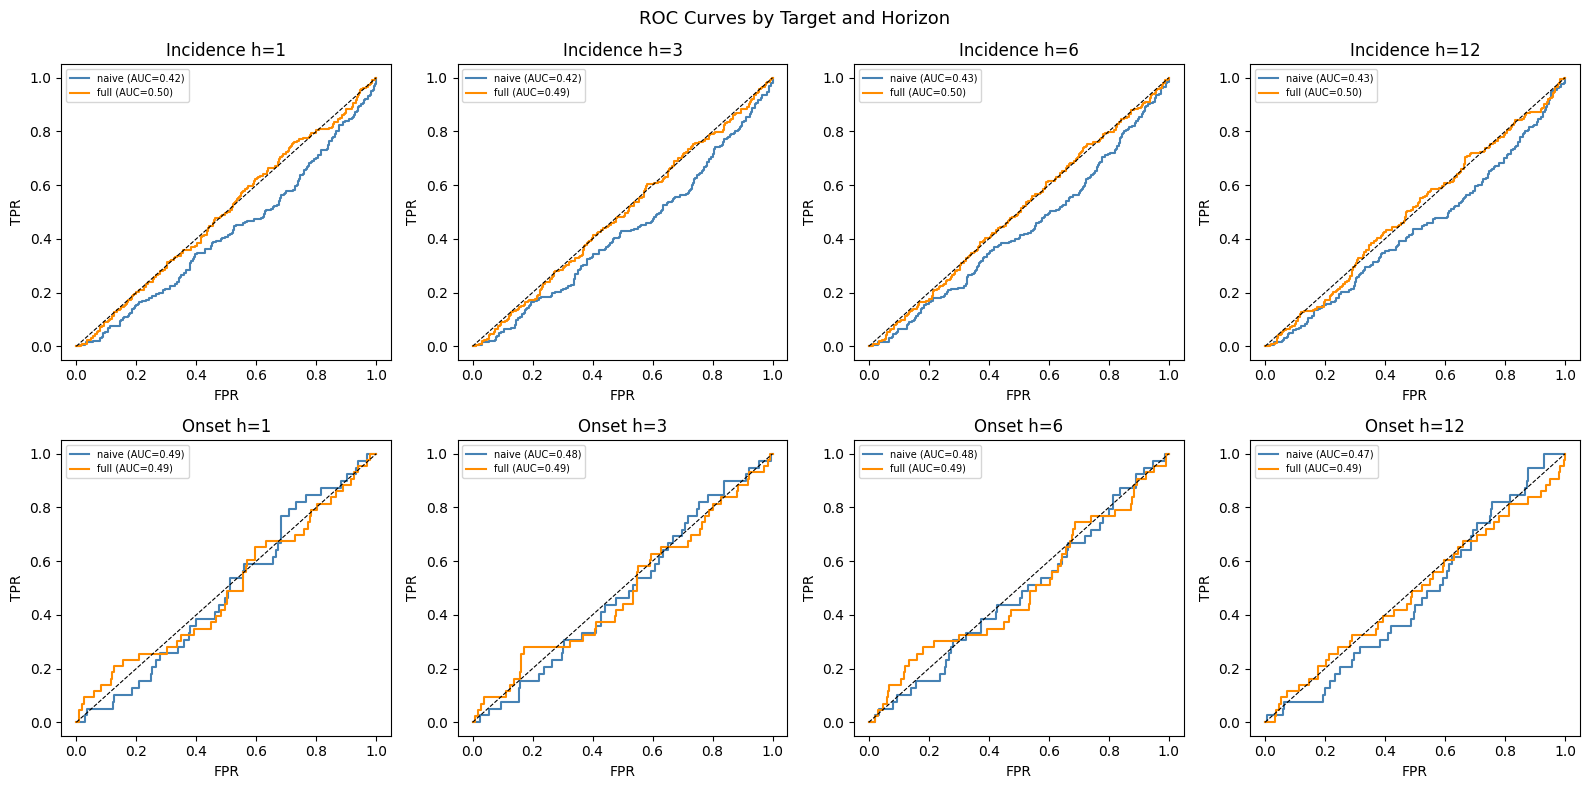

In [31]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
horizons = [1, 3, 6, 12]

for col, h in enumerate(horizons):
    for row, (results, target_name) in enumerate([
        (results_incidence, "incidence_dev_12m"),
        (results_onset,     "onset_dev_12m"),
    ]):
        ax = axes[row, col]
        for name, color in [("naive", "steelblue"), ("full", "darkorange")]:
            d = results[(h, name)]
            preds = d["preds"]
            model_df = d["model_df"].reset_index(drop=True)
            y_prob = preds[:, 1] if len(preds.shape) == 2 else preds
            y_true = model_df[target_name].dropna().astype(int)
            min_len = min(len(y_true), len(y_prob))
            y_true = y_true.iloc[:min_len].values
            y_prob = y_prob[:min_len]
            if len(np.unique(y_true)) < 2:
                continue
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            auc = roc_auc_score(y_true, y_prob)
            ax.plot(fpr, tpr, color=color, label=f"{name} (AUC={auc:.2f})")
        ax.plot([0,1],[0,1], "k--", lw=0.8)
        ax.set_title(f"{target_name.split('_')[0].capitalize()} h={h}")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(fontsize=7)

plt.suptitle("ROC Curves by Target and Horizon", fontsize=13)
plt.tight_layout()
plt.show()


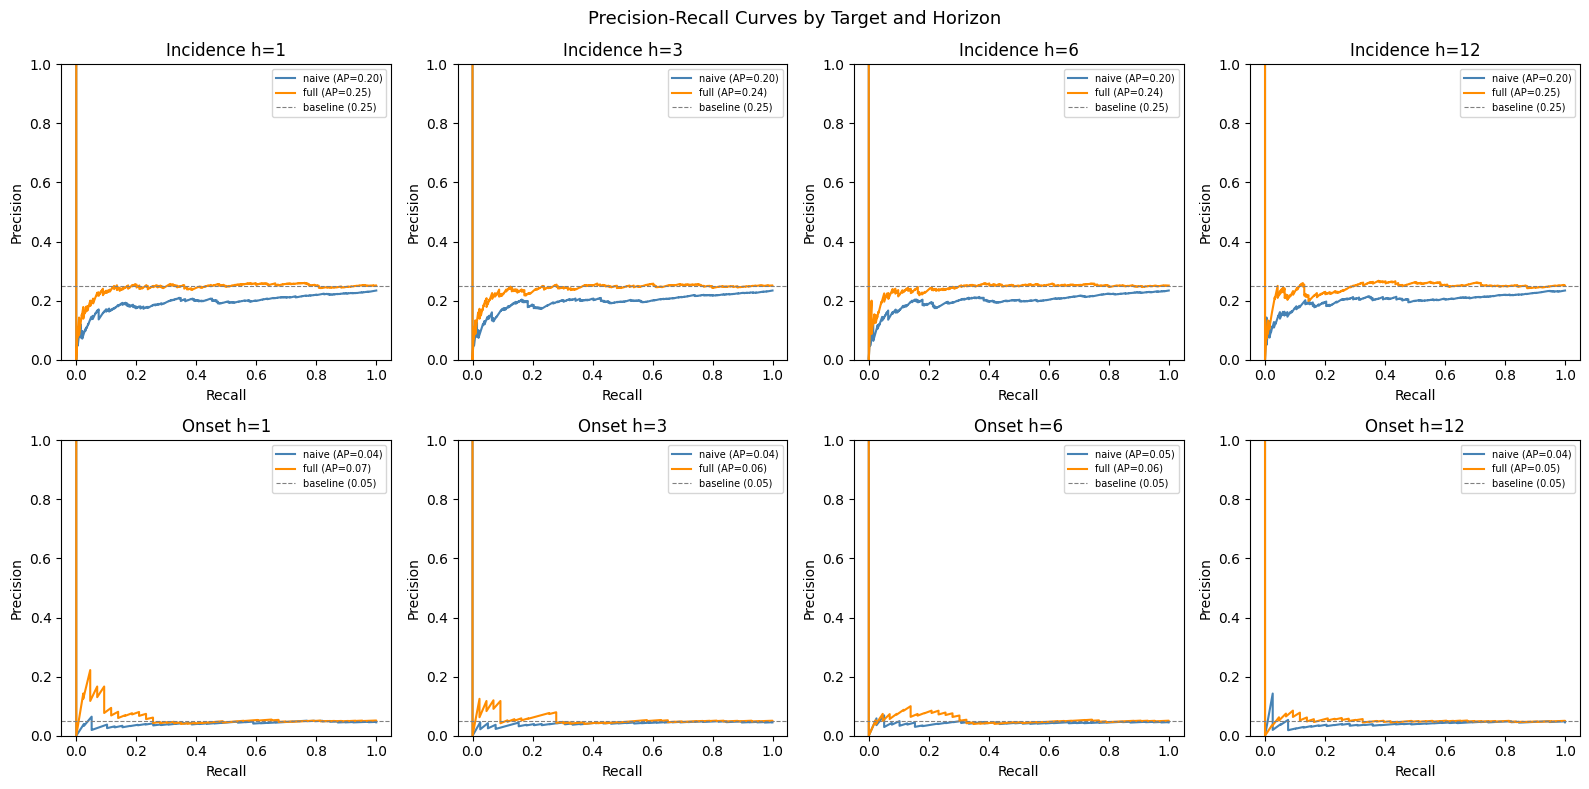

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, h in enumerate(horizons):
    for row, (results, target_name) in enumerate([
        (results_incidence, "incidence_dev_12m"),
        (results_onset,     "onset_dev_12m"),
    ]):
        ax = axes[row, col]
        for name, color in [("naive", "steelblue"), ("full", "darkorange")]:
            d = results[(h, name)]
            preds = d["preds"]
            model_df = d["model_df"].reset_index(drop=True)
            y_prob = preds[:, 1] if len(preds.shape) == 2 else preds
            y_true = model_df[target_name].dropna().astype(int)
            min_len = min(len(y_true), len(y_prob))
            y_true = y_true.iloc[:min_len].values
            y_prob = y_prob[:min_len]
            if len(np.unique(y_true)) < 2:
                continue
            prec, rec, _ = precision_recall_curve(y_true, y_prob)
            ap = average_precision_score(y_true, y_prob)
            baseline = y_true.mean()
            ax.plot(rec, prec, color=color, label=f"{name} (AP={ap:.2f})")
        ax.axhline(baseline, color="gray", linestyle="--", lw=0.8, label=f"baseline ({baseline:.2f})")
        ax.set_title(f"{target_name.split('_')[0].capitalize()} h={h}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7)

plt.suptitle("Precision-Recall Curves by Target and Horizon", fontsize=13)
plt.tight_layout()
plt.show()


In [33]:
h, gap = 6, 5
d = results_incidence[(h, "full")]
preds = d["preds"]
model_df = d["model_df"].copy().reset_index(drop=True)

# reconstruct test indices from the same CV split
p = model_df["period"]
cv_p = PanelSplit(periods=p, n_splits=48, test_size=1, gap=gap)
test_indices = np.concatenate([test for _, test in cv_p.split(model_df)])

assert len(test_indices) == len(preds), f"{len(test_indices)} vs {len(preds)}"

pred_df = model_df.iloc[test_indices].copy().reset_index(drop=True)
pred_df["y_prob"] = preds[:, 1]
pred_df["y_true"] = pred_df["incidence_dev_12m"].astype(int)

country_auc = {}
for country in pred_df["isocode"].unique():
    sub = pred_df[pred_df["isocode"] == country]
    if sub["y_true"].nunique() < 2 or len(sub) < 5:
        continue
    country_auc[country] = roc_auc_score(sub["y_true"], sub["y_prob"])

auc_series = pd.Series(country_auc).sort_values()
print("Worst 5:\n", auc_series.head())
print("\nBest 5:\n", auc_series.tail())


Worst 5:
 CHL    0.460317
ITA    0.461101
EST    0.462500
NOR    0.473043
FIN    0.488203
dtype: float64

Best 5:
 HUN    0.542857
BRA    0.554688
POL    0.561616
BEL    0.562500
CZE    0.568058
dtype: float64


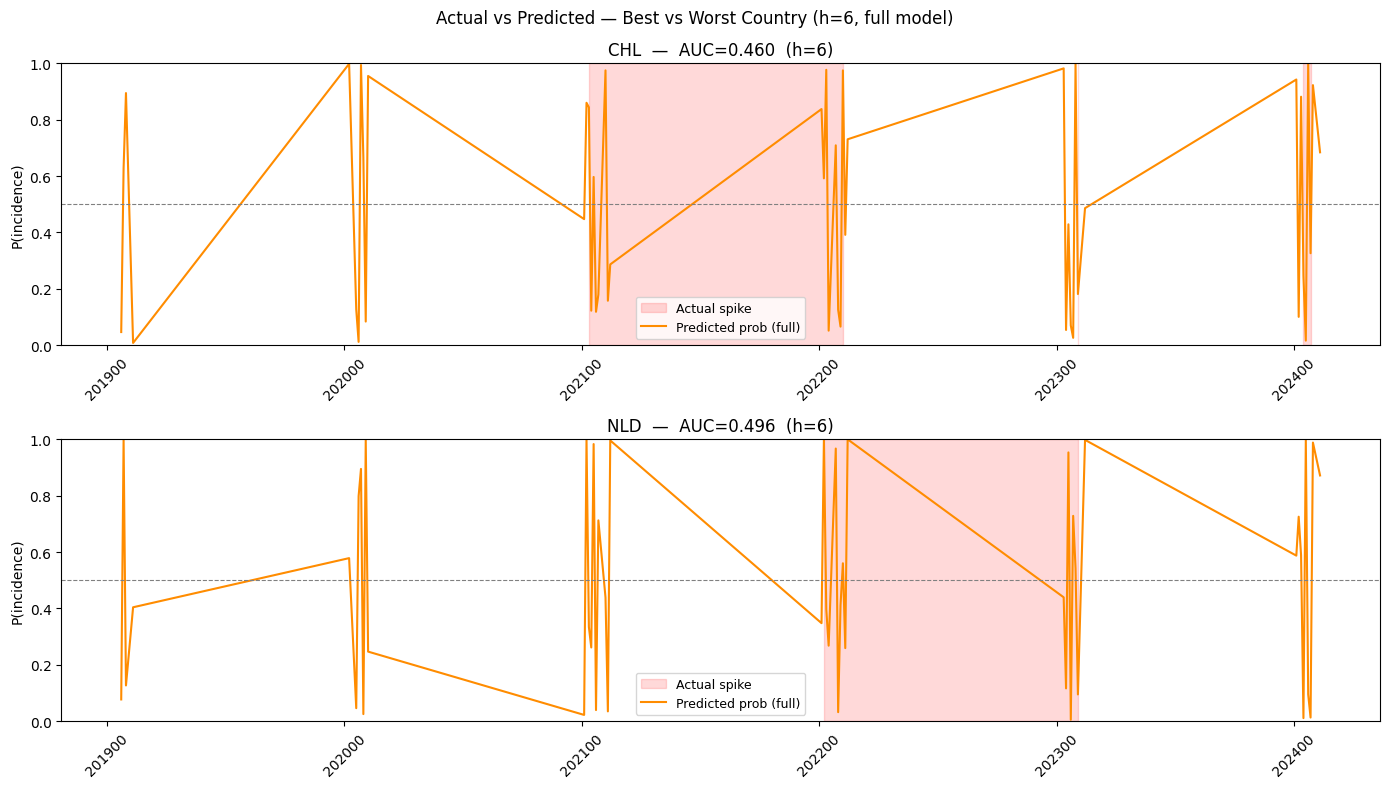

In [34]:
best_iso, worst_iso = "CHL", "NLD"

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, iso in zip(axes, [best_iso, worst_iso]):
    sub = pred_df[pred_df["isocode"] == iso].sort_values("period")
    ax.fill_between(sub["period"], 0, 1,
                    where=sub["y_true"] == 1,
                    alpha=0.15, color="red", label="Actual spike")
    ax.plot(sub["period"], sub["y_prob"], color="darkorange", lw=1.5, label="Predicted prob (full)")
    ax.axhline(0.5, color="gray", lw=0.8, linestyle="--")
    auc = country_auc[iso]
    ax.set_title(f"{iso}  —  AUC={auc:.3f}  (h=6)")
    ax.set_ylabel("P(incidence)")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    # rotate x labels
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Actual vs Predicted — Best vs Worst Country (h=6, full model)", fontsize=12)
plt.tight_layout()
plt.show()
